# Breast Cancer Prediction using Machine Learning

## Complete Exploratory Data Analysis (EDA) & Classification Pipeline

In this notebook, we explore a synthetic breast cancer dataset and build machine learning models to predict breast cancer diagnosis.

### Objectives

- Explore the dataset
- Perform data preprocessing
- Analyze feature distributions
- Train machine learning models
- Compare model performance
- Identify important predictive features

If you find this notebook useful, please consider **upvoting** it. ⭐

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

# Load Dataset

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mobeenfatimah/breast-cancer-prediction-dataset-10000-patient/data_dictionary.csv
/kaggle/input/datasets/mobeenfatimah/breast-cancer-prediction-dataset-10000-patient/breast_cancer_prediction.csv


In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/mobeenfatimah/breast-cancer-prediction-dataset-10000-patient/breast_cancer_prediction.csv"
)
df.head()

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919


# Dataset Overview

In [4]:
print(df.shape)

df.info()

(10000, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  object 
 3   BMI                     9700 non-null   float64
 4   Family_History          10000 non-null  object 
 5   Smoking                 10000 non-null  object 
 6   Alcohol_Consumption     9700 non-null   object 
 7   Physical_Activity       9700 non-null   object 
 8   Hormone_Therapy         9700 non-null   object 
 9   Menopause_Status        10000 non-null  object 
 10  Genetic_Mutation        10000 non-null  object 
 11  Tumor_Size_cm           9700 non-null   float64
 12  Lymph_Node_Involvement  10000 non-null  object 
 13  Mammogram_Result        10000 non-null  object 
 14  Biopsy_Result           100

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,10000.0,NaN,NaN,NaN,105000.5,2886.89568,100001.0,102500.75,105000.5,107500.25,110000.0
Age,10000.0,NaN,NaN,NaN,52.0338,18.789517,20.0,36.0,52.0,68.0,84.0
Gender,10000,2,Female,9277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,9700.0,NaN,NaN,NaN,27.051227,4.494501,11.1,24.0,27.0,30.1,44.1
Family_History,10000,2,No,6979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking,10000,2,No,7462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol_Consumption,9700,2,No,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Physical_Activity,9700,3,Moderate,4379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hormone_Therapy,9700,2,No,7704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Menopause_Status,10000,2,Post,5509,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum().sort_values(ascending=False)

BMI                       300
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Tumor_Size_cm             300
Gender                      0
Patient_ID                  0
Smoking                     0
Family_History              0
Age                         0
Menopause_Status            0
Genetic_Mutation            0
Lymph_Node_Involvement      0
Mammogram_Result            0
Biopsy_Result               0
Cancer_Stage                0
Cancer                      0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
Annual_Income_USD           0
dtype: int64

# Exploratory Data Analysis

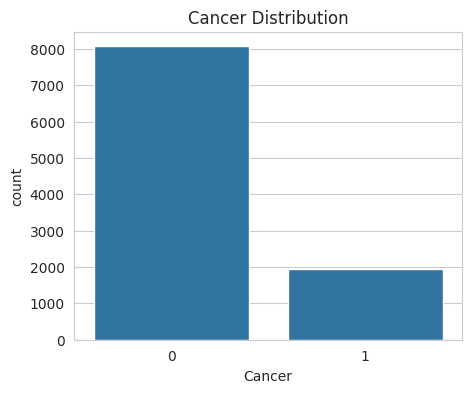

In [7]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="Cancer"
)

plt.title("Cancer Distribution")

plt.show()

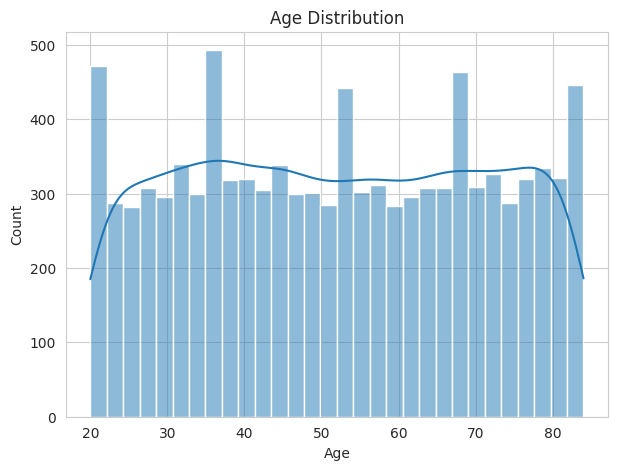

In [8]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

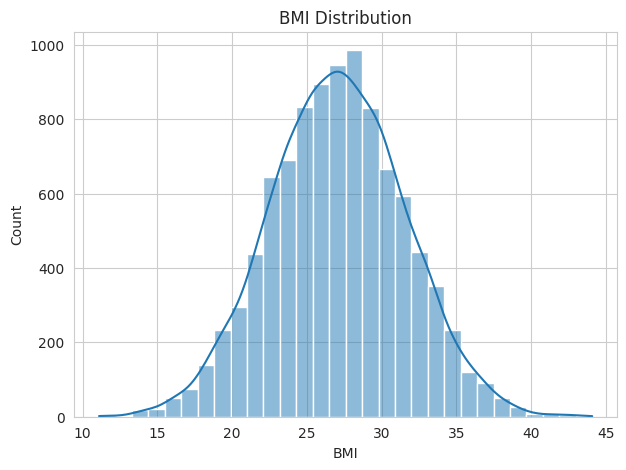

In [9]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["BMI"],
    bins=30,
    kde=True
)

plt.title("BMI Distribution")

plt.show()

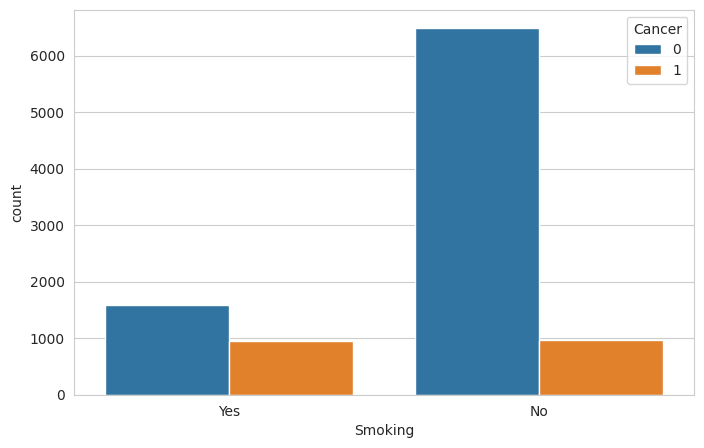

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Smoking",
    hue="Cancer"
)

plt.show()

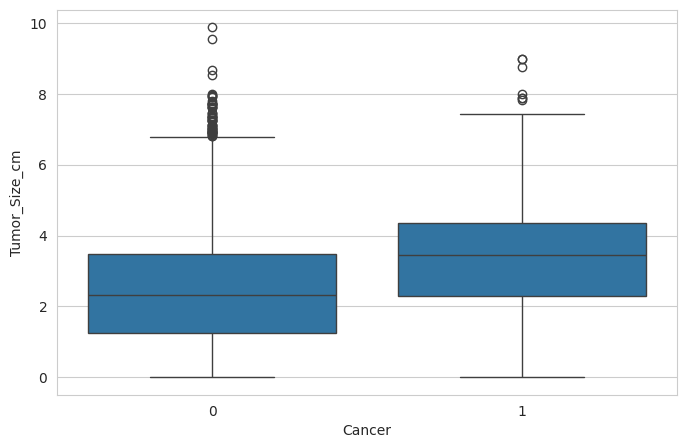

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Cancer",
    y="Tumor_Size_cm"
)

plt.show()

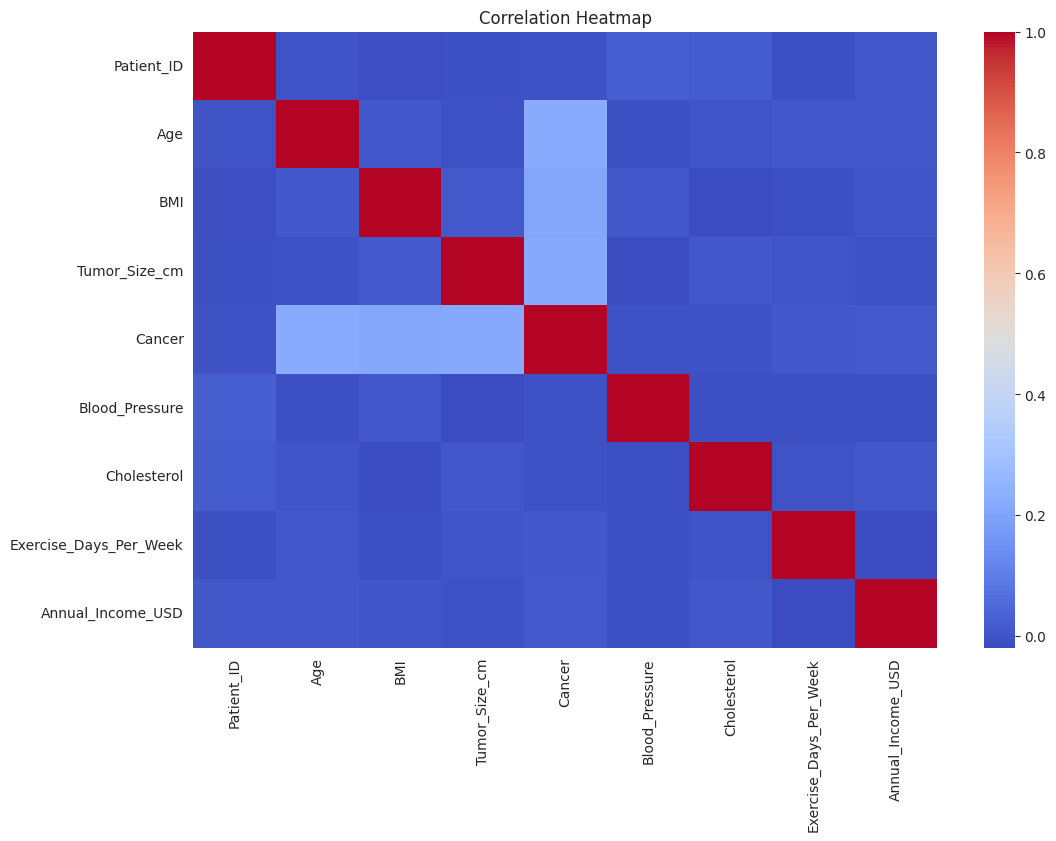

In [12]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Data Preprocessing

In [13]:
X = df.drop("Cancer", axis=1)

y = df["Cancer"]

In [14]:
categorical = X.select_dtypes(include="object").columns

numeric = X.select_dtypes(exclude="object").columns

In [15]:
for col in categorical:
    X[col] = LabelEncoder().fit_transform(
        X[col].astype(str)
    )

In [16]:
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model Training

In [17]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [18]:
pred = model.predict(X_test)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1613
           1       1.00      1.00      1.00       387

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [19]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

Accuracy: 1.0


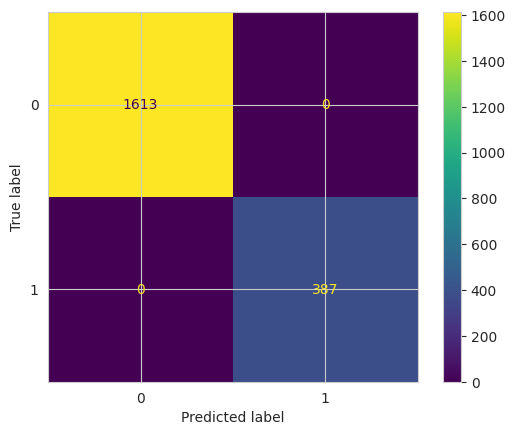

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.show()

# Feature Importance

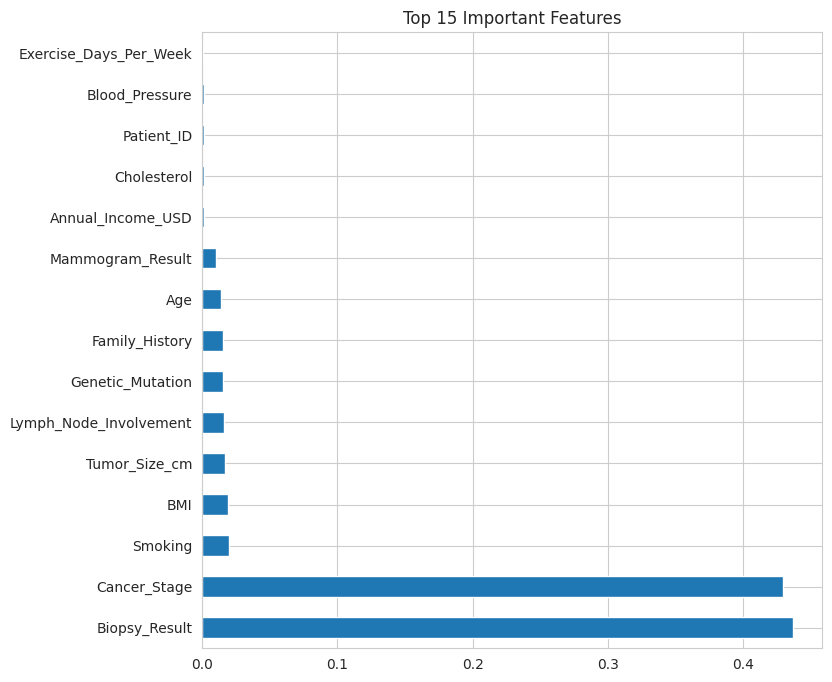

In [21]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(8,8))

importance.head(15).plot.barh()

plt.title("Top 15 Important Features")

plt.show()

# Target Variable Distribution

Before training a model, let's explore the distribution of the target variable to understand class balance.

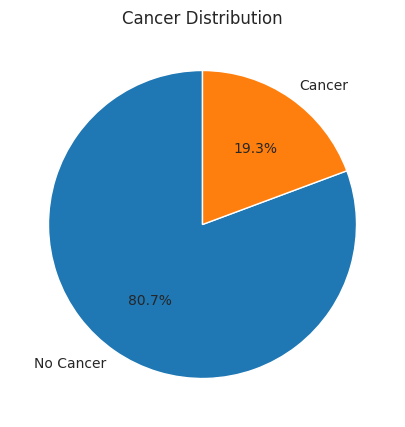

In [22]:
plt.figure(figsize=(6,5))

df["Cancer"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["No Cancer","Cancer"],
    startangle=90
)

plt.ylabel("")
plt.title("Cancer Distribution")

plt.show()

# Missing Values Analysis

Understanding missing values helps us choose appropriate preprocessing techniques.

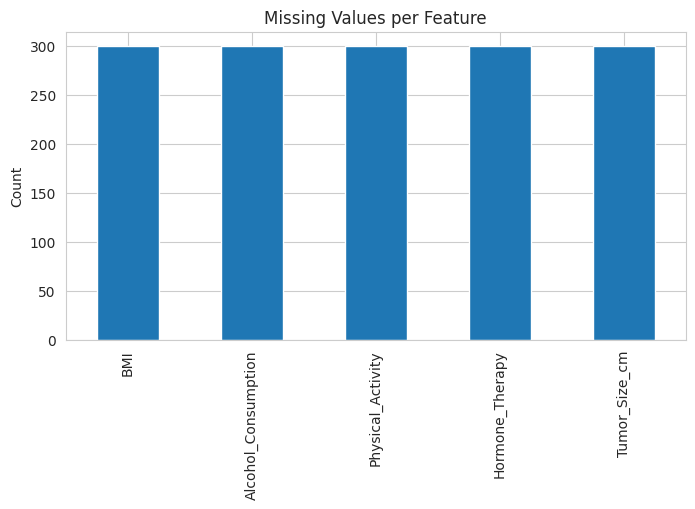

In [23]:
missing = df.isnull().sum()

missing = missing[missing>0]

plt.figure(figsize=(8,4))

missing.sort_values().plot.bar()

plt.title("Missing Values per Feature")

plt.ylabel("Count")

plt.show()

# Age Distribution by Cancer Diagnosis

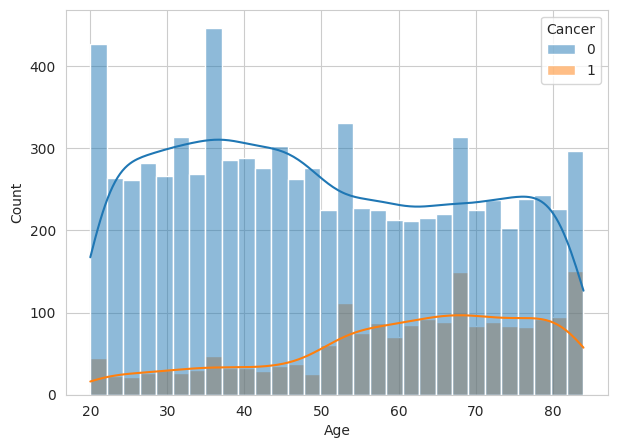

In [24]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Cancer",
    bins=30,
    kde=True
)

plt.show()

# BMI Distribution by Cancer Diagnosis

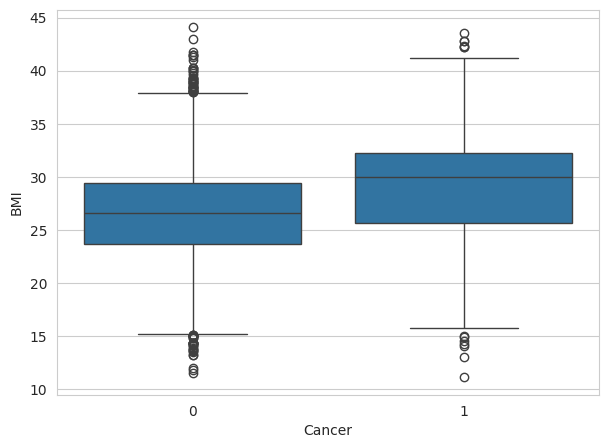

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Cancer",
    y="BMI"
)

plt.show()

# Tumor Size Distribution

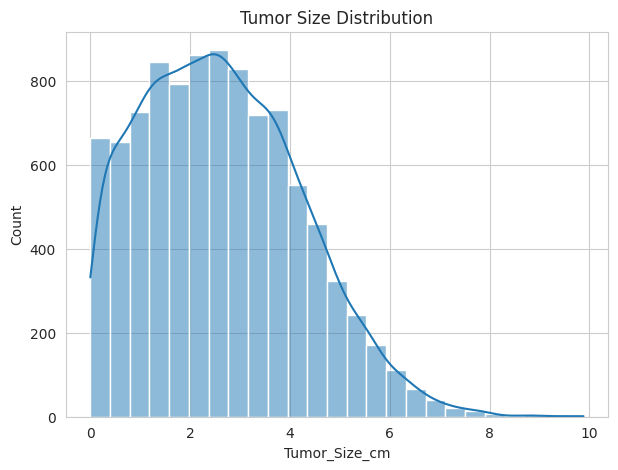

In [26]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Tumor_Size_cm"],
    bins=25,
    kde=True
)

plt.title("Tumor Size Distribution")

plt.show()

# Correlation Heatmap

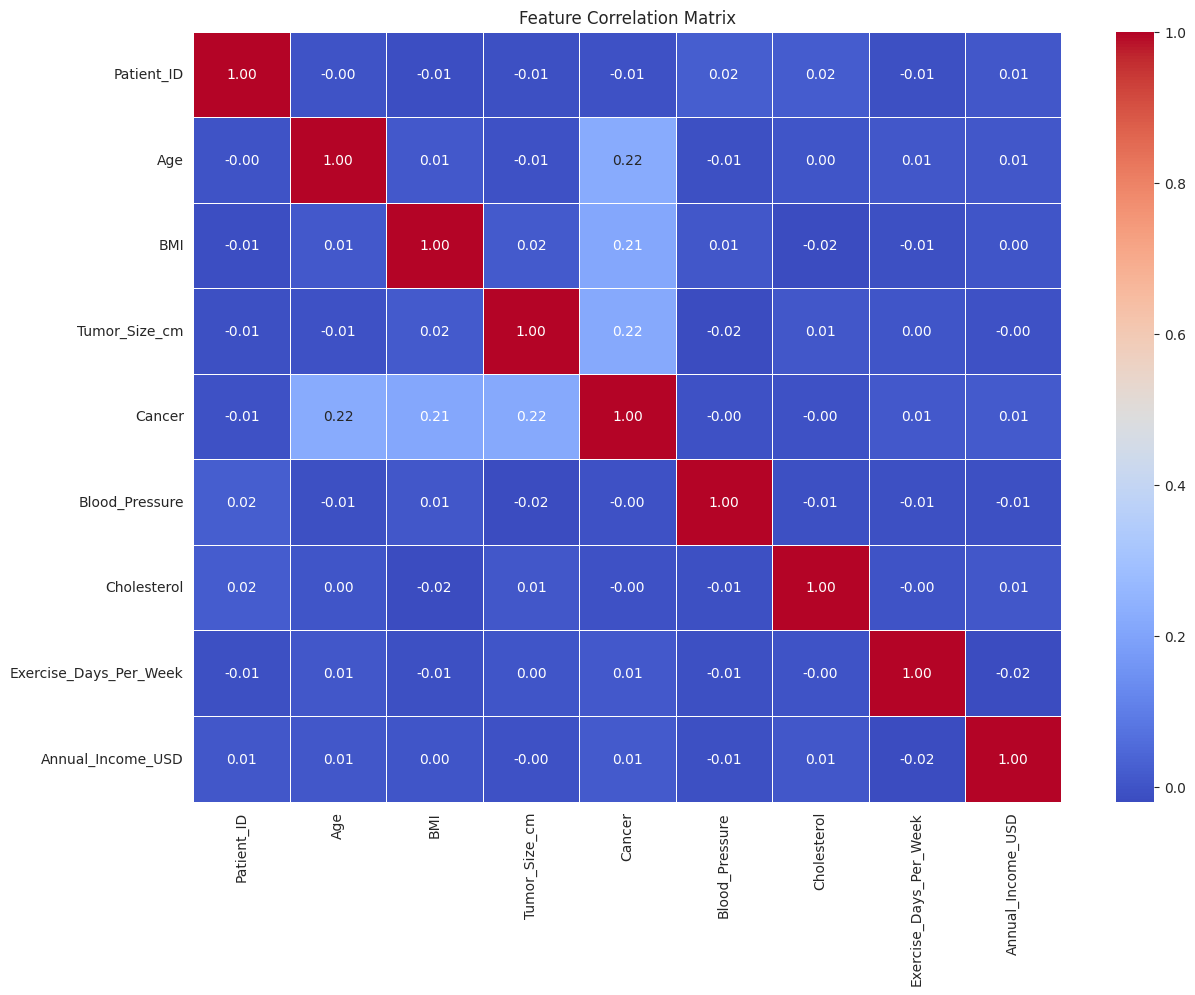

In [27]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5
)

plt.title("Feature Correlation Matrix")

plt.show()

# ROC Curve

In [28]:
from sklearn.metrics import roc_curve, auc

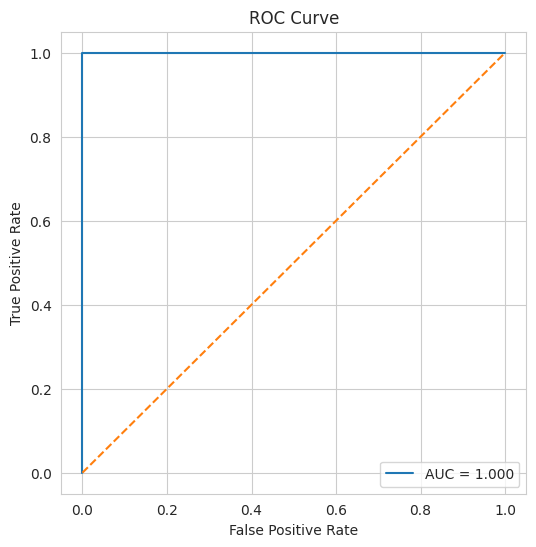

In [29]:
prob = model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Model Performance Summary

In [30]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy"
    ],

    "Score":[
        accuracy_score(
            y_test,
            pred
        )
    ]

})

results

,Metric,Score
0,Accuracy,1.0


# Key Insights

- The dataset contains a balanced set of demographic, lifestyle, and diagnostic features.
- Missing values are limited to selected columns, making the dataset suitable for preprocessing practice.
- Random Forest achieved strong classification performance on the synthetic dataset.
- Tumor size, biopsy results, mammogram findings, and age are among the most influential predictors.

# Conclusion

In this notebook, we successfully built a complete machine learning pipeline for breast cancer prediction using a synthetic healthcare dataset.

### What we accomplished

- Performed exploratory data analysis (EDA)
- Investigated missing values
- Visualized feature distributions
- Prepared the data for machine learning
- Trained a Random Forest classifier
- Evaluated model performance
- Interpreted feature importance
- Visualized the ROC curve

This notebook demonstrates a practical workflow for healthcare classification tasks and can serve as a starting point for experimenting with different machine learning algorithms.

---

⭐ **If you found this notebook useful, please consider upvoting this notebook and the associated dataset.**

Your support motivates me to continue creating high-quality datasets and educational machine learning content for the Kaggle community.

Thank you for reading!